# Heart Disease Risk Factor Analysis
**Dataset:** heart.csv | **Records:** 999 | **Target:** Heart_Disease (Yes/No)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('heart.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (999, 11)


,General_Health,Exercise,Depression,Diabetes,Sex,Age_Category,Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Heart_Disease
0,Poor,No,No,No,Female,70-74,32.66,14.54,Yes,No,No
1,Very Good,No,No,Yes,Female,70-74,77.11,28.29,No,No,Yes
2,Very Good,Yes,No,Yes,Female,60-64,88.45,33.47,No,No,No
3,Poor,Yes,No,Yes,Male,75-79,93.44,28.73,No,Yes,Yes
4,Good,No,No,No,Male,80+,88.45,24.37,Yes,Yes,No


## 1. Dataset Overview

In [2]:
print('=== Basic Info ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Target Distribution ===')
print(df['Heart_Disease'].value_counts())
print(f"\nHeart Disease Rate: {df['Heart_Disease'].eq('Yes').mean()*100:.1f}%")

=== Basic Info ===
General_Health          object
Exercise                object
Depression              object
Diabetes                object
Sex                     object
Age_Category            object
Weight_(kg)            float64
BMI                    float64
Smoking_History         object
Alcohol_Consumption     object
Heart_Disease           object
dtype: object

=== Missing Values ===
General_Health         0
Exercise               0
Depression             0
Diabetes               0
Sex                    0
Age_Category           0
Weight_(kg)            0
BMI                    0
Smoking_History        0
Alcohol_Consumption    0
Heart_Disease          0
dtype: int64

=== Target Distribution ===
Heart_Disease
No     858
Yes    141
Name: count, dtype: int64

Heart Disease Rate: 14.1%


In [3]:
print('=== Numerical Summary ===')
df[['Weight_(kg)', 'BMI']].describe().round(2)

=== Numerical Summary ===


,Weight_(kg),BMI
count,999.00,999.00
mean,81.00,28.56
std,19.80,6.22
min,32.66,14.06
25%,67.59,24.21
50%,79.38,27.78
75%,91.17,31.89
max,167.83,51.81


## 2. Risk Factor Distribution

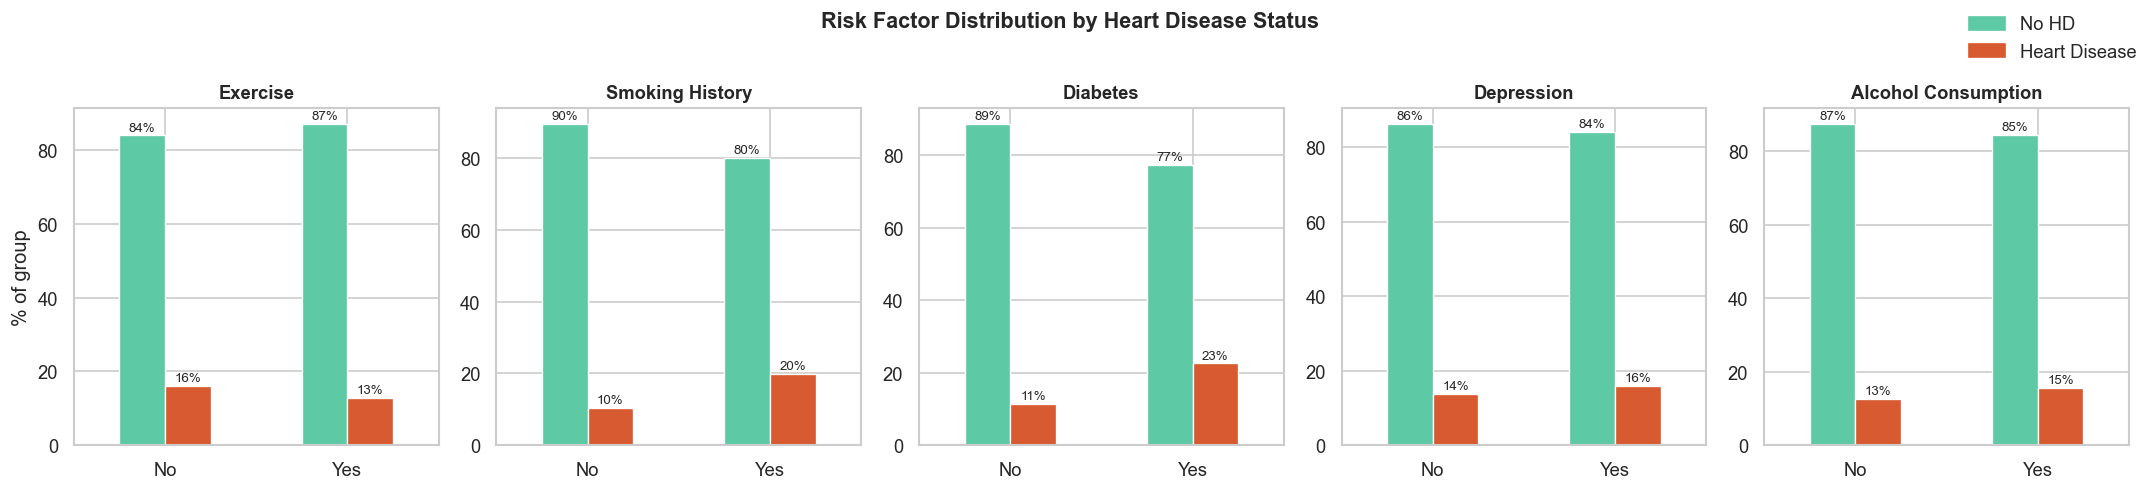

In [4]:
risk_factors = ['Exercise', 'Smoking_History', 'Diabetes', 'Depression', 'Alcohol_Consumption']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
colors = ['#5DCAA5', '#D85A30']

for ax, col in zip(axes, risk_factors):
    ct = df.groupby([col, 'Heart_Disease']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax, color=colors, edgecolor='white', linewidth=0.8, rot=0)
    ax.set_title(col.replace('_', ' '), fontsize=11, fontweight='bold')
    ax.set_ylabel('% of group' if ax == axes[0] else '')
    ax.set_xlabel('')
    ax.legend_.remove()
    for p in ax.patches:
        h = p.get_height()
        if h > 3:
            ax.annotate(f'{h:.0f}%', (p.get_x() + p.get_width()/2, h + 0.5),
                        ha='center', va='bottom', fontsize=8)

legend_patches = [mpatches.Patch(color=colors[0], label='No HD'),
                  mpatches.Patch(color=colors[1], label='Heart Disease')]
fig.legend(handles=legend_patches, loc='upper right', frameon=False)
fig.suptitle('Risk Factor Distribution by Heart Disease Status', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# Heart Disease Rate per risk factor
print('Heart Disease Rate by Risk Factor\n')
for col in risk_factors:
    ct = df.groupby([col, 'Heart_Disease']).size().unstack(fill_value=0)
    ct['HD_rate_%'] = (ct['Yes'] / ct.sum(axis=1) * 100).round(1)
    print(f'--- {col} ---')
    print(ct[['No', 'Yes', 'HD_rate_%']])
    print()

Heart Disease Rate by Risk Factor

--- Exercise ---
Heart_Disease   No  Yes  HD_rate_%
Exercise                          
No             337   64       16.0
Yes            521   77       12.9

--- Smoking_History ---
Heart_Disease     No  Yes  HD_rate_%
Smoking_History                     
No               543   63       10.4
Yes              315   78       19.8

--- Diabetes ---
Heart_Disease   No  Yes  HD_rate_%
Diabetes                          
No             666   85       11.3
Yes            192   56       22.6

--- Depression ---
Heart_Disease   No  Yes  HD_rate_%
Depression                        
No             714  114       13.8
Yes            144   27       15.8

--- Alcohol_Consumption ---
Heart_Disease         No  Yes  HD_rate_%
Alcohol_Consumption                     
No                   410   59       12.6
Yes                  448   82       15.5



## 3. General Health vs Heart Disease

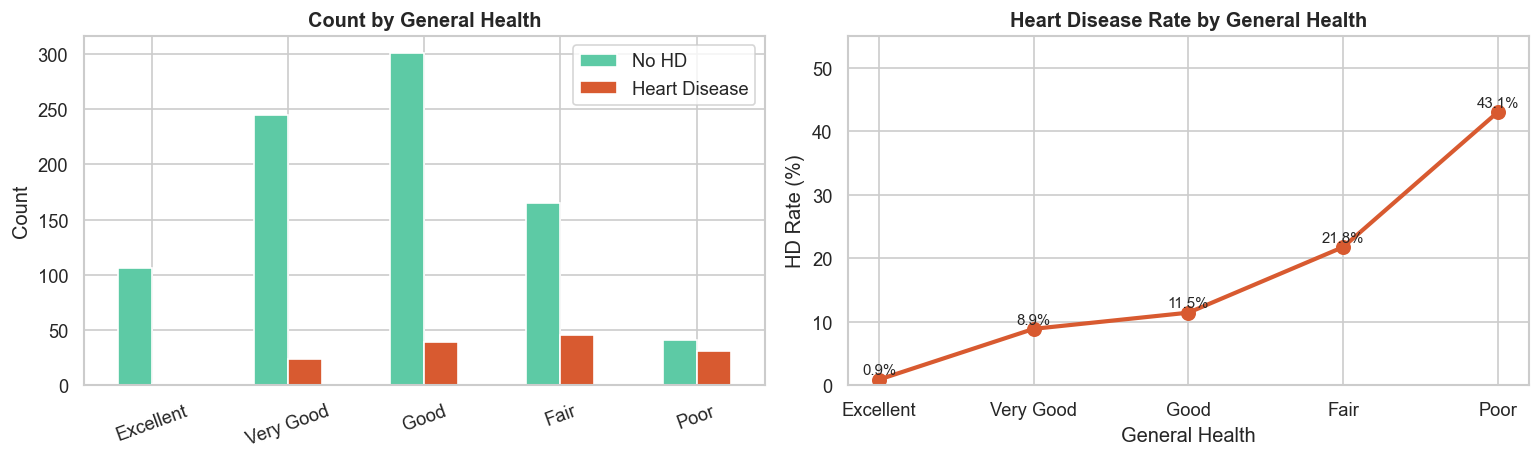

Heart_Disease    No  Yes    HD_rate
General_Health                     
Excellent       106    1   0.934579
Very Good       245   24   8.921933
Good            301   39  11.470588
Fair            165   46  21.800948
Poor             41   31  43.055556


In [6]:
health_order = ['Excellent', 'Very Good', 'Good', 'Fair', 'Poor']

ct = df.groupby(['General_Health', 'Heart_Disease']).size().unstack(fill_value=0)
ct = ct.reindex(health_order)
ct['HD_rate'] = ct['Yes'] / ct.sum(axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart: counts
ct[['No', 'Yes']].plot(kind='bar', ax=axes[0], color=['#5DCAA5', '#D85A30'],
                        edgecolor='white', rot=20)
axes[0].set_title('Count by General Health', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].legend(['No HD', 'Heart Disease'])

# Line chart: HD rate
axes[1].plot(health_order, ct['HD_rate'], marker='o', color='#D85A30', linewidth=2.5, markersize=8)
for i, (x, y) in enumerate(zip(health_order, ct['HD_rate'])):
    axes[1].annotate(f'{y:.1f}%', (x, y + 0.8), ha='center', fontsize=9)
axes[1].set_title('Heart Disease Rate by General Health', fontweight='bold')
axes[1].set_ylabel('HD Rate (%)')
axes[1].set_xlabel('General Health')
axes[1].set_ylim(0, 55)

plt.tight_layout()
plt.show()
print(ct)

## 4. Age vs Heart Disease Outcome

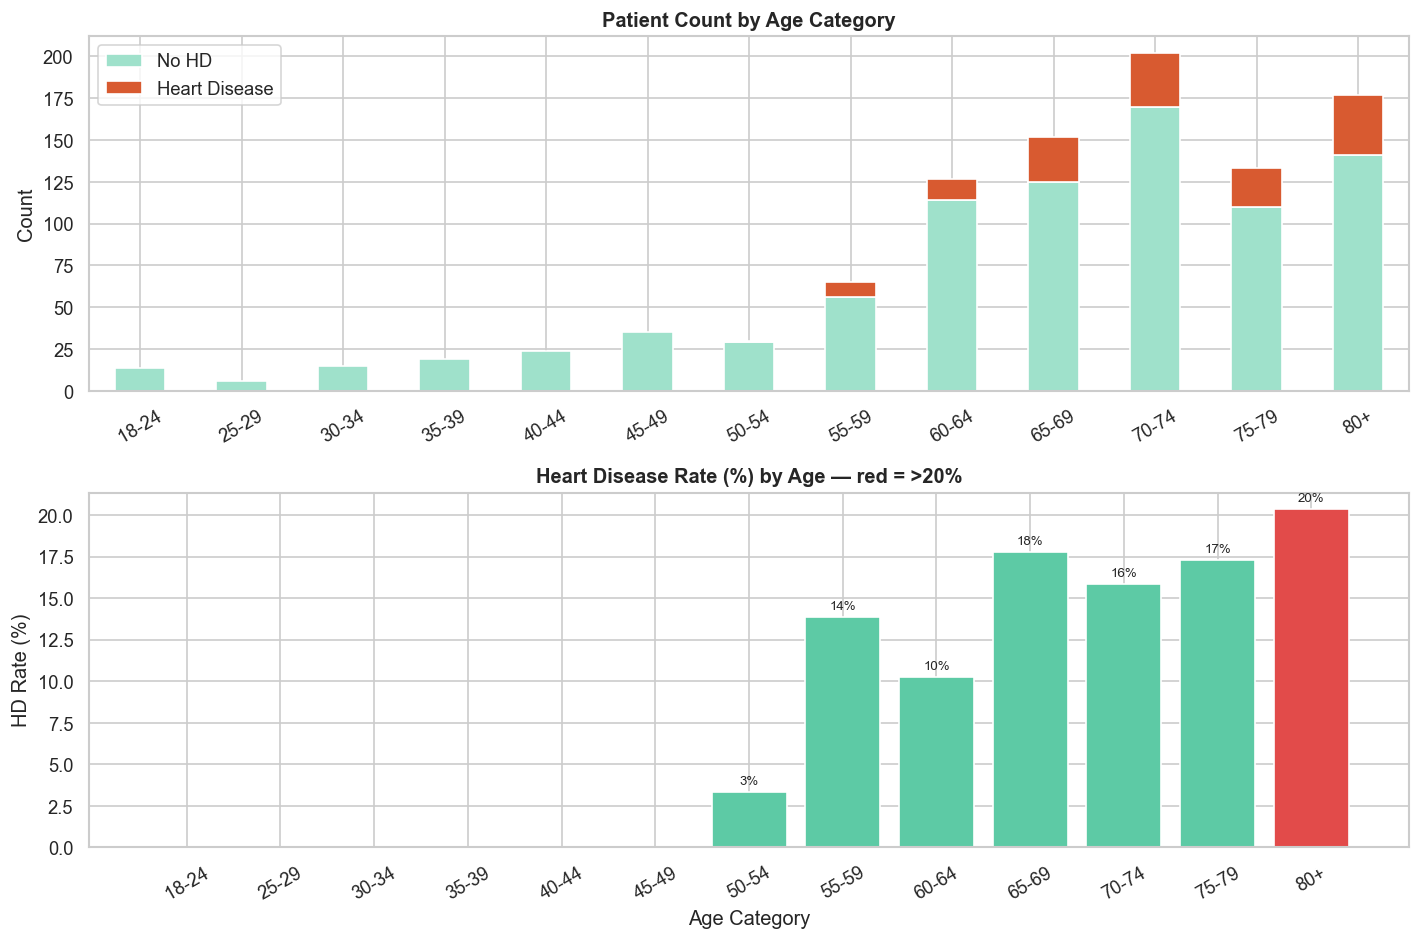

Heart_Disease   No  Yes    HD_rate
Age_Category                      
18-24           14    0   0.000000
25-29            6    0   0.000000
30-34           15    0   0.000000
35-39           19    0   0.000000
40-44           24    0   0.000000
45-49           35    0   0.000000
50-54           29    1   3.333333
55-59           56    9  13.846154
60-64          114   13  10.236220
65-69          125   27  17.763158
70-74          170   32  15.841584
75-79          110   23  17.293233
80+            141   36  20.338983


In [7]:
age_order = ['18-24','25-29','30-34','35-39','40-44','45-49',
             '50-54','55-59','60-64','65-69','70-74','75-79','80+']

age_ct = df.groupby(['Age_Category', 'Heart_Disease']).size().unstack(fill_value=0)
age_ct = age_ct.reindex(age_order)
age_ct['HD_rate'] = age_ct['Yes'] / age_ct.sum(axis=1) * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Stacked bar
age_ct[['No', 'Yes']].plot(kind='bar', stacked=True, ax=axes[0],
                            color=['#9FE1CB', '#D85A30'], edgecolor='white', rot=30)
axes[0].set_title('Patient Count by Age Category', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].legend(['No HD', 'Heart Disease'], loc='upper left')

# HD rate by age
bars = axes[1].bar(age_order, age_ct['HD_rate'],
                   color=['#E24B4A' if r > 20 else '#5DCAA5' for r in age_ct['HD_rate']],
                   edgecolor='white')
for bar, val in zip(bars, age_ct['HD_rate']):
    if val > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.0f}%', ha='center', va='bottom', fontsize=8)
axes[1].set_title('Heart Disease Rate (%) by Age — red = >20%', fontweight='bold')
axes[1].set_xlabel('Age Category')
axes[1].set_ylabel('HD Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
print(age_ct)

## 5. BMI & Weight Distribution

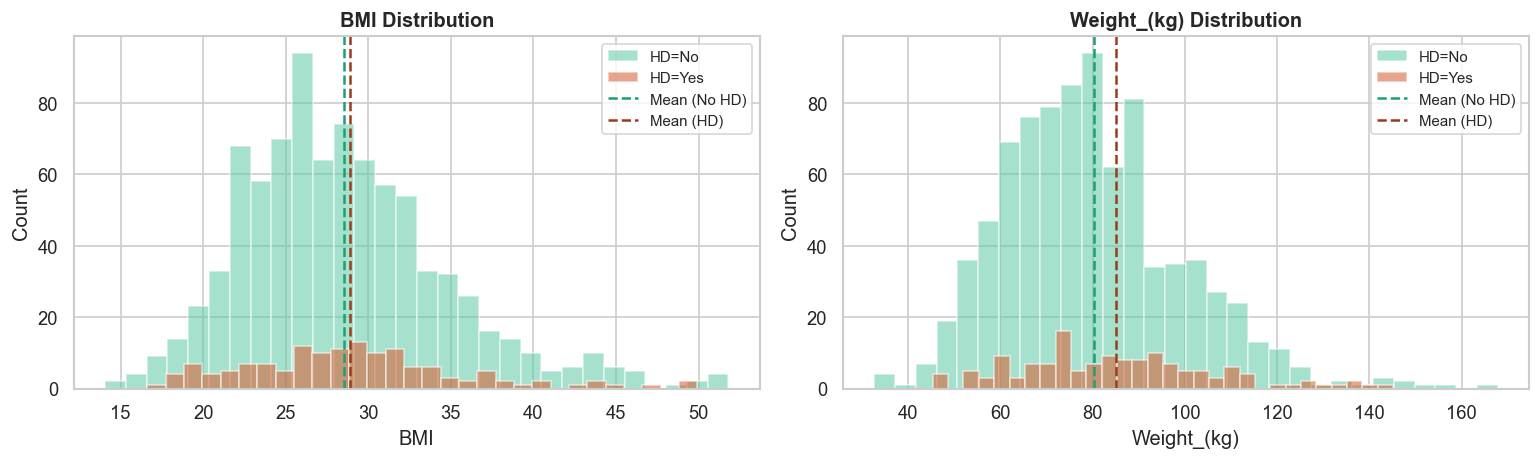


BMI Stats by Heart Disease:
               count   mean   std    min    25%    50%    75%    max
Heart_Disease                                                       
No             858.0  28.51  6.17  14.06  24.21  27.48  31.83  51.81
Yes            141.0  28.90  6.52  16.62  24.63  28.48  32.10  49.92

Weight Stats by Heart Disease:
               count   mean    std    min    25%    50%    75%     max
Heart_Disease                                                         
No             858.0  80.32  19.50  32.66  66.68  78.24  90.72  167.83
Yes            141.0  85.13  21.17  45.36  70.31  83.91  97.52  145.15


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col in zip(axes, ['BMI', 'Weight_(kg)']):
    for label, color, ls in [('No', '#5DCAA5', '-'), ('Yes', '#D85A30', '--')]:
        subset = df[df['Heart_Disease'] == label][col]
        ax.hist(subset, bins=30, alpha=0.55, color=color, label=f'HD={label}', edgecolor='white')
    ax.axvline(df[df['Heart_Disease']=='No'][col].mean(), color='#1D9E75', linestyle='--', linewidth=1.5, label='Mean (No HD)')
    ax.axvline(df[df['Heart_Disease']=='Yes'][col].mean(), color='#993C1D', linestyle='--', linewidth=1.5, label='Mean (HD)')
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('\nBMI Stats by Heart Disease:')
print(df.groupby('Heart_Disease')['BMI'].describe().round(2))
print('\nWeight Stats by Heart Disease:')
print(df.groupby('Heart_Disease')['Weight_(kg)'].describe().round(2))

## 6. Correlation Heatmap (Encoded Features)

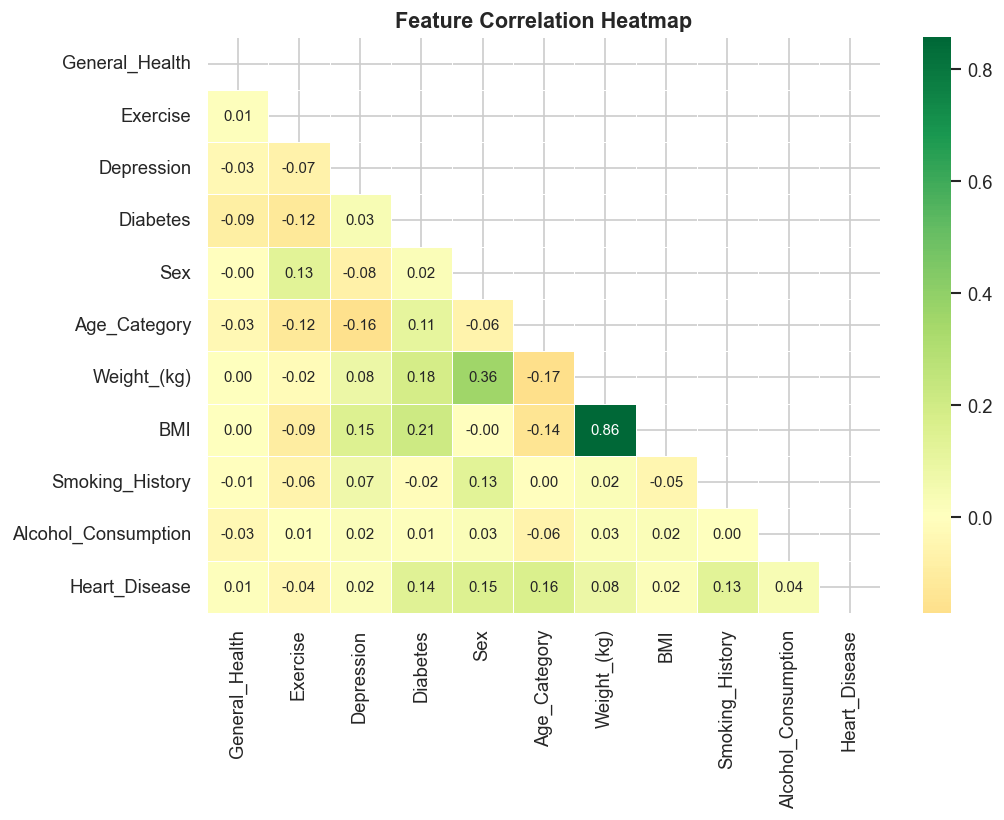

In [9]:
from sklearn.preprocessing import LabelEncoder

df_enc = df.copy()
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

corr = df_enc.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Key Findings Summary

In [10]:
findings = {
    'Overall HD Rate': f"{df['Heart_Disease'].eq('Yes').mean()*100:.1f}%",
    'HD Rate – Smokers': '19.8%',
    'HD Rate – Non-Smokers': '10.4%',
    'HD Rate – Diabetics': '22.6%',
    'HD Rate – Non-Diabetics': '11.3%',
    'HD Rate – Poor Health': '43.1%',
    'HD Rate – Excellent Health': '0.9%',
    'HD Rate – Age 80+': '20.3%',
    'HD Rate – Age <50': '0%',
    'Avg BMI (HD=Yes)': f"{df[df['Heart_Disease']=='Yes']['BMI'].mean():.1f}",
    'Avg BMI (HD=No)': f"{df[df['Heart_Disease']=='No']['BMI'].mean():.1f}",
    'Avg Weight (HD=Yes)': f"{df[df['Heart_Disease']=='Yes']['Weight_(kg)'].mean():.1f} kg",
    'Avg Weight (HD=No)': f"{df[df['Heart_Disease']=='No']['Weight_(kg)'].mean():.1f} kg",
}

print('=' * 42)
print('       KEY FINDINGS — HEART DISEASE')
print('=' * 42)
for k, v in findings.items():
    print(f'  {k:<30} {v}')
print('=' * 42)

       KEY FINDINGS — HEART DISEASE
  Overall HD Rate                14.1%
  HD Rate – Smokers              19.8%
  HD Rate – Non-Smokers          10.4%
  HD Rate – Diabetics            22.6%
  HD Rate – Non-Diabetics        11.3%
  HD Rate – Poor Health          43.1%
  HD Rate – Excellent Health     0.9%
  HD Rate – Age 80+              20.3%
  HD Rate – Age <50              0%
  Avg BMI (HD=Yes)               28.9
  Avg BMI (HD=No)                28.5
  Avg Weight (HD=Yes)            85.1 kg
  Avg Weight (HD=No)             80.3 kg
